In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("salary_pred.csv")
df.head()

,Experience_Years,Salary
0,11.24,71321.38
1,28.52,161348.14
2,21.96,143688.19
3,17.96,108061.27
4,4.68,64526.34


In [3]:
df.shape

(10000, 2)

In [4]:
X = df[['Experience_Years']]
y = df['Salary']

In [5]:
x = np.array(X).reshape(-1,1)
Y = np.array(y).reshape(-1,1)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(x, Y, test_size=0.3, random_state=42)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred = model.predict(X_test)

In [25]:
print("slope:", model.coef_[0])
print("Intercept:", model.intercept_)


slope: [4992.47776016]
Intercept: [30357.61674411]


In [26]:
print("mean_absolute_error:",mean_absolute_error(y_test, y_pred))

mean_absolute_error: 7832.611088264932


In [27]:
print("mean_squared_error:",mean_squared_error(y_test, y_pred))

mean_squared_error: 98117868.68984298


In [28]:
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE: 9905.446415474822


In [29]:
print("r2 score:",r2_score(y_test, y_pred))

r2 score: 0.949066603228428


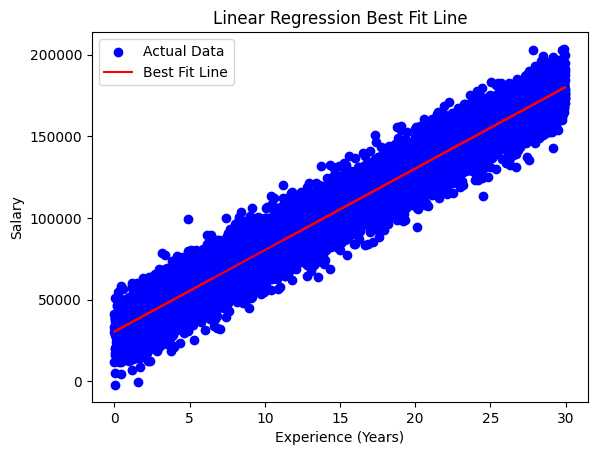

In [30]:
plt.scatter(x, Y, color="blue", label="Actual Data")
plt.plot(x, model.predict(x), color="red", label="Best Fit Line")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Linear Regression Best Fit Line")
plt.legend()
plt.show()

In [31]:
# Use the trained model to predict salary of new data points.
salary_test =[[12]]
n_pred=model.predict(salary_test)
print("\nPrediction for new data :", n_pred)


Prediction for new data : [[90267.34986597]]
